In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Imortamos el dataset.
df = pd.read_csv('Superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
# Revisamos la información del dataset.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

El conjunto de datos contiene 9,994 registros y 21 columnas, con información relacionada a pedidos, clientes, productos y ventas.

Incluye datos como fechas de compra y envío, ubicación del cliente, categorías de productos y métricas clave como ventas, cantidad, descuento y ganancia.

No se identifican valores faltantes, por lo que los datos se encuentran completos para su análisis.

In [4]:
# Revisamos las estadísticas descriptivas del dataset.
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


# Resumen estadístico de los datos

Se obtuvo un resumen estadístico de las variables numéricas, mostrando métricas como promedio, valores mínimos, máximos y percentiles.

Los resultados indican una alta variabilidad en las ventas y ganancias, con valores que van desde pérdidas significativas hasta ganancias elevadas. Además, se observa que los descuentos pueden alcanzar hasta el 80%, lo que puede impactar directamente en la rentabilidad.

En general, los datos presentan una distribución amplia, lo que sugiere la presencia de valores extremos en algunas variables.

In [5]:
resumen_regional = df.groupby(['Region', 'Category'])[['Sales', 'Profit']].sum().reset_index()
pivot = resumen_regional.pivot(index='Region', columns='Category', values='Sales')
display(resumen_regional)
display(pivot)

,Region,Category,Sales,Profit
0,Central,Furniture,163797.1638,-2871.0494
1,Central,Office Supplies,167026.4150,8879.9799
2,Central,Technology,170416.3120,33697.4320
3,East,Furniture,208291.2040,3046.1658
4,East,Office Supplies,205516.0550,41014.5791
5,East,Technology,264973.9810,47462.0351
6,South,Furniture,117298.6840,6771.2061
7,South,Office Supplies,125651.3130,19986.3928
8,South,Technology,148771.9080,19991.8314
9,West,Furniture,252612.7435,11504.9503


Category,Furniture,Office Supplies,Technology
Region,,,
Central,163797.1638,167026.415,170416.312
East,208291.2040,205516.055,264973.981
South,117298.6840,125651.313,148771.908
West,252612.7435,220853.249,251991.832


# Descripción de los datos

Se agruparon las ventas y ganancias por región y categoría de producto. Los resultados muestran que la categoría de Technology genera las mayores ventas en todas las regiones, especialmente en la región East.

En cuanto a las ganancias, la mayoría de las combinaciones son positivas, excepto Furniture en la región Central, donde se presentan pérdidas. Además, la región West destaca por tener altos niveles de ventas y ganancias en varias categorías.

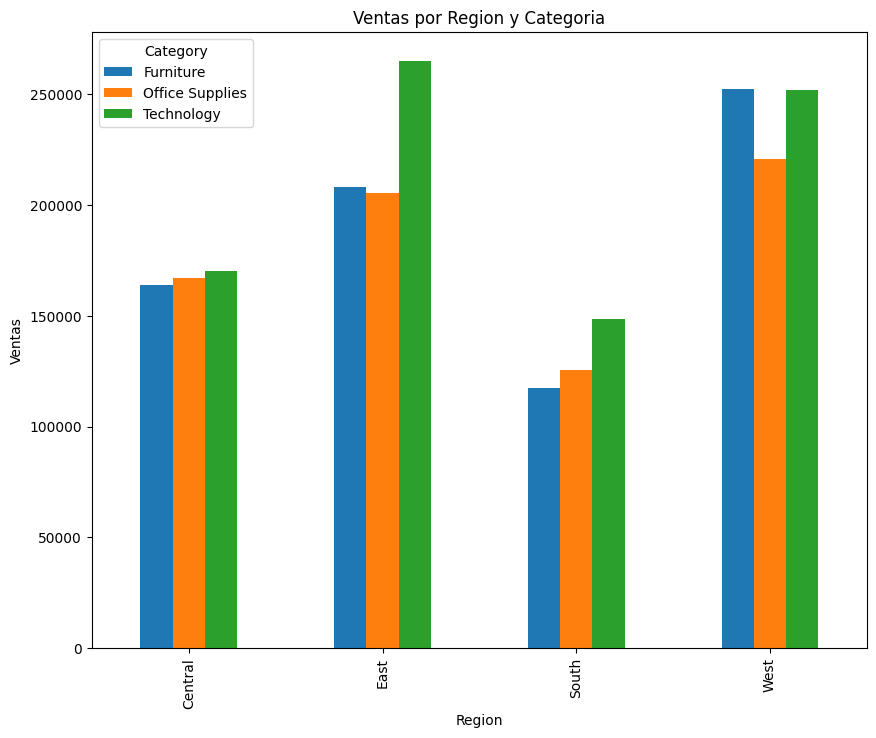

In [6]:
pivot.plot(kind='bar',figsize=(10, 8))
plt.title('Ventas por Region y Categoria')
plt.ylabel('Ventas')
plt.xlabel('Region')
plt.show()

La gráfica muestra la comparación de ventas por región y categoría. Se observa que la categoría Technology lidera en la mayoría de las regiones, con un pico notable en East.

La región West también presenta altos niveles de ventas en todas las categorías, mientras que South registra los valores más bajos en comparación con las demás regiones. En general, se identifican diferencias claras en el rendimiento de ventas entre regiones y categorías.

In [7]:
resumen_subcategoria = df.groupby(['Region', 'Sub-Category'])[['Sales', 'Profit']].sum().reset_index()
resumen_subcategoria = resumen_subcategoria.sort_values(by=['Region', 'Profit'], ascending=[True, False])
display(resumen_subcategoria)

,Region,Sub-Category,Sales,Profit
6,Central,Copiers,37259.5700,15608.8413
13,Central,Phones,72403.2820,12323.0267
0,Central,Accessories,33956.0760,7251.6306
12,Central,Paper,17491.9020,6971.9005
5,Central,Chairs,85230.6460,6592.7221
...,...,...,...,...
67,West,Tables,84754.5620,1482.6073
66,West,Supplies,18127.1220,626.0465
59,West,Fasteners,923.2160,275.1907
62,West,Machines,42444.1220,-618.9264


# Descripción de los datos (Subcategorías)

Se agruparon las ventas y ganancias por región y subcategoría de productos. Los resultados muestran que algunas subcategorías como Copiers y Phones destacan por generar altas ganancias, especialmente en ciertas regiones.

También se identifican subcategorías con bajo rendimiento o pérdidas, como Machines y Bookcases en la región West. En general, el desempeño varía considerablemente entre subcategorías, evidenciando cuáles aportan mayor rentabilidad y cuáles representan áreas de mejora.

In [11]:
resumen_descuentos = df.groupby('Segment')[['Discount', 'Profit']].mean().reset_index()
display(resumen_descuentos)

,Segment,Discount,Profit
0,Consumer,0.158141,25.836873
1,Corporate,0.158228,30.456667
2,Home Office,0.147128,33.818664


# Descripción de los datos (Segmento de clientes)

Se analizaron los descuentos y ganancias promedio por segmento de clientes. Los resultados muestran que el segmento Home Office presenta la mayor ganancia promedio, a pesar de tener un nivel de descuento ligeramente menor.

Por otro lado, los segmentos Consumer y Corporate tienen niveles de descuento muy similares, aunque Corporate logra una mayor ganancia promedio que Consumer. En general, se observan diferencias en la rentabilidad según el tipo de cliente.

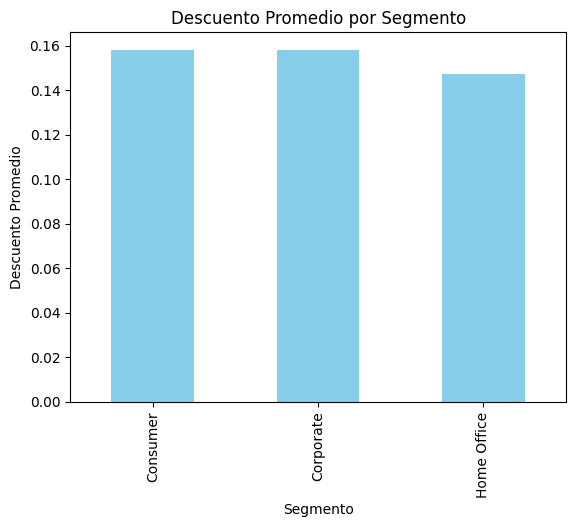

In [12]:
df.groupby('Segment')['Discount'].mean().plot(kind='bar', color='skyblue', title='Descuento Promedio por Segmento')
plt.ylabel('Descuento Promedio')
plt.xlabel('Segmento')
plt.show()

La gráfica muestra el descuento promedio por segmento de clientes. Se observa que los segmentos Consumer y Corporate tienen niveles de descuento muy similares, mientras que Home Office presenta un descuento ligeramente menor.

En general, no hay grandes diferencias entre los segmentos, aunque Home Office destaca por manejar descuentos más bajos en comparación con los demás.

In [13]:
pivot_table = pd.pivot_table(df, values='Sales', index='Region', columns='Segment', aggfunc='sum', fill_value=0)
display(pivot_table)

Segment,Consumer,Corporate,Home Office
Region,,,
Central,252031.434,157995.8128,91212.6440
East,350908.167,200409.3470,127463.7260
South,195580.971,121885.9325,74255.0015
West,362880.773,225855.2745,136721.7770


# Descripción de los datos (Ventas por segmento y región)

Se analizaron las ventas por segmento de clientes en cada región. Los resultados muestran que el segmento Consumer lidera en ventas en todas las regiones, seguido por Corporate y finalmente Home Office.

Además, la región West y East presentan los valores más altos de ventas en todos los segmentos, mientras que South registra los niveles más bajos.

In [14]:
cross_tab = pd.crosstab(df['Category'], df['Region'])
display(cross_tab)

Region,Central,East,South,West
Category,,,,
Furniture,481,601,332,707
Office Supplies,1422,1712,995,1897
Technology,420,535,293,599


# Descripción de los datos (Cantidad de pedidos por categoría y región)

Se evaluó la cantidad de pedidos por categoría en cada región. La categoría Office Supplies concentra la mayor cantidad de pedidos en todas las regiones, seguida por Furniture y Technology.

También se observa que la región West tiene el mayor volumen de pedidos en todas las categorías, mientras que South presenta la menor actividad.